In [92]:
import os
import gc
import math
import random
import warnings
warnings.filterwarnings('ignore')


import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import Ridge


import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor


SEED = 42
N_FOLDS = 5
TARGET = 'Age'


random.seed(SEED)
np.random.seed(SEED)



In [42]:
# Data Loading

train_path="/kaggle/input/phitron-contest/train.csv"
test_path="/kaggle/input/phitron-contest/test.csv"

train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)

print(train.shape, test.shape)

(15000, 10) (10000, 9)


In [43]:
train.isnull().sum()




id                0
Sex               0
Length            0
Diameter          0
Height            0
Weight            0
Shucked Weight    0
Viscera Weight    0
Shell Weight      0
Age               0
dtype: int64

In [44]:
# Sanity Checks
assert TARGET in train.columns
assert 'id' in train.columns
assert 'id' in test.columns


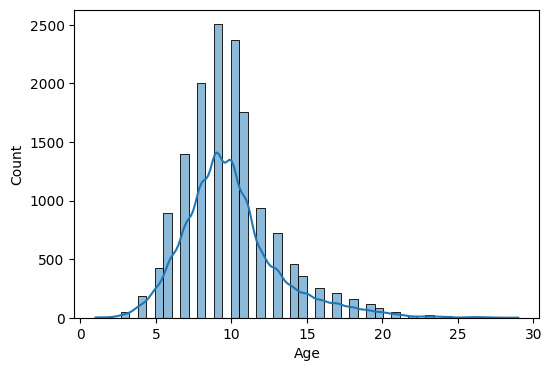

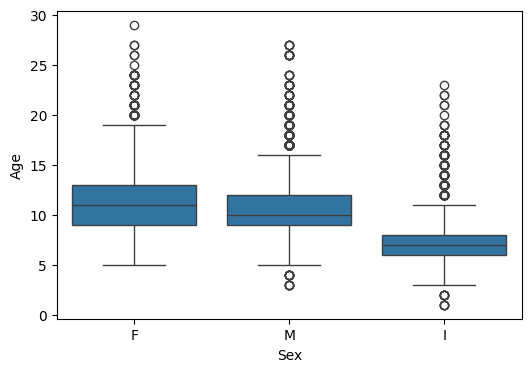

In [45]:
# Smart EDA

train.describe().T

plt.figure(figsize=(6,4))
sns.histplot(train[TARGET], bins=50, kde=True)
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='Sex', y=TARGET, data=train)
plt.show()

In [71]:
# train[f'{TARGET}_log'] = np.log1p(train[TARGET])
# train[[TARGET, f'{TARGET}_log']].describe().T



In [72]:
# plt.figure(figsize=(12,4))

# plt.subplot(1,2,1)
# sns.histplot(train[TARGET], bins=50, kde=True)
# plt.title('Original TARGET')

# plt.subplot(1,2,2)
# sns.histplot(train[f'{TARGET}_log'], bins=50, kde=True)
# plt.title('Log Transformed TARGET')

# plt.tight_layout()
# plt.show()



# plt.figure(figsize=(6,4))
# sns.boxplot(x='Sex', y=f'{TARGET}_log', data=train)
# plt.title('Log Transformed TARGET by Sex')
# plt.show()


In [35]:
# Target transformation

y = np.log1p(train[TARGET])




In [36]:
# Feature Engineering

def feature_engineering(df):
    df = df.copy()

    # Ratios
    df['shucked_ratio'] = df['Shucked Weight'] / (df['Weight'] + 1e-6)
    df['viscera_ratio'] = df['Viscera Weight'] / (df['Weight'] + 1e-6)
    df['shell_ratio']   = df['Shell Weight'] / (df['Weight'] + 1e-6)

    # Geometry
    df['volume'] = df['Length'] * df['Diameter'] * df['Height']
    df['area']   = df['Length'] * df['Diameter']

    # Density
    df['density'] = df['Weight'] / (df['volume'] + 1e-6)

    # Log features
    for c in ['Weight', 'volume', 'Shell Weight', 'Height']:
        df[f'log_{c}'] = np.log1p(df[c])

    # Sex interaction (important)
    df['Sex_weight'] = df['Weight'] * (df['Sex'] == 'M').astype(int)

    df.replace([np.inf, -np.inf], 0, inplace=True)
    df.fillna(0, inplace=True)
    return df


In [49]:
train = feature_engineering(train)
test  = feature_engineering(test)


In [51]:
# Train / Test Split

X = train.drop([TARGET, "id"], axis=1)
y = np.log1p(train[TARGET])
X_test = test.drop("id", axis=1)

In [54]:
# Fix column names
X.columns = X.columns.str.replace(" ", "_")
X_test.columns = X_test.columns.str.replace(" ", "_")

In [57]:
# Encode Categoricals (for LGB & XGB)

cat_cols = [c for c in X.columns if X[c].dtype == "object"]

for c in cat_cols:
    le = LabelEncoder()
    X[c] = le.fit_transform(X[c])
    X_test[c] = le.transform(X_test[c])

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)


In [60]:
# CatBoost Model

cat_oof = np.zeros(len(X))
cat_test = np.zeros(len(X_test))

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

for fold, (tr, val) in enumerate(kf.split(X)):
    model = CatBoostRegressor(
        iterations=8000,
        depth=10,
        learning_rate=0.02,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=SEED,
        l2_leaf_reg=5,
        bagging_temperature=0.8,
        early_stopping_rounds=300,
        verbose=500
    )

    model.fit(
        X.iloc[tr], y.iloc[tr],
        eval_set=(X.iloc[val], y.iloc[val]),
        cat_features=cat_cols
    )

    cat_oof[val] = model.predict(X.iloc[val])
    cat_test += model.predict(X_test) / 5

print("CatBoost R2:", r2_score(y, cat_oof))


0:	learn: 0.2800759	test: 0.2804641	best: 0.2804641 (0)	total: 36.2ms	remaining: 4m 49s
500:	learn: 0.1431171	test: 0.1552772	best: 0.1552724 (491)	total: 18s	remaining: 4m 29s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.1552724289
bestIteration = 491

Shrink model to first 492 iterations.
0:	learn: 0.2810332	test: 0.2765488	best: 0.2765488 (0)	total: 35ms	remaining: 4m 40s
500:	learn: 0.1439730	test: 0.1528408	best: 0.1528349 (498)	total: 18s	remaining: 4m 29s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.1528019911
bestIteration = 566

Shrink model to first 567 iterations.
0:	learn: 0.2785769	test: 0.2864669	best: 0.2864669 (0)	total: 38.1ms	remaining: 5m 4s
500:	learn: 0.1416518	test: 0.1599724	best: 0.1598286 (350)	total: 18.1s	remaining: 4m 31s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.1598286371
bestIteration = 350

Shrink model to first 351 iterations.
0:	learn: 0.2806570	test: 0.2778666	best: 0.2778666 (

In [65]:
# LightGBM Model

import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np

lgb_oof = np.zeros(len(X))
lgb_test = np.zeros(len(X_test))

for fold, (tr, val) in enumerate(kf.split(X)):
    model = lgb.LGBMRegressor(
        n_estimators=8000,
        learning_rate=0.02,
        num_leaves=96,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.2,
        random_state=SEED
    )

    model.fit(
        X.iloc[tr], y.iloc[tr],
        eval_set=[(X.iloc[val], y.iloc[val])],
        eval_metric='rmse',
        callbacks=[lgb.early_stopping(300)]
    )

    lgb_oof[val] = model.predict(X.iloc[val])
    lgb_test += model.predict(X_test) / 5

print("LGB R2:", r2_score(y, lgb_oof))



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000506 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3892
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 19
[LightGBM] [Info] Start training from score 2.350952
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[178]	valid_0's rmse: 0.155197	valid_0's l2: 0.0240861
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001371 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3897
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 19
[LightGBM] [Info] Start training from score 2.352713
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[18

In [76]:
import xgboost as xgb

xgb_oof = np.zeros(len(X))
xgb_test = np.zeros(len(X_test))

for fold, (tr, val) in enumerate(kf.split(X)):
    model = xgb.XGBRegressor(
        n_estimators=5000,
        learning_rate=0.03,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        random_state=SEED
    )

    # Fit without early stopping (version safe)
    model.fit(
        X.iloc[tr], y.iloc[tr],
        verbose=False
    )

    xgb_oof[val] = model.predict(X.iloc[val])
    xgb_test += model.predict(X_test) / N_FOLDS

print("XGBoost R2:", r2_score(y, xgb_oof))



XGBoost R2: 0.6602588428897828


In [87]:
# Weighted Ensemble

ensemble_oof = 0.5*cat_oof + 0.3*lgb_oof + 0.2*xgb_oof
print('Ensemble R2:', r2_score(y, ensemble_oof))


Ensemble R2: 0.6959558328168862


In [88]:
# Stacking Meta-Model

meta_X = np.column_stack([cat_oof, lgb_oof, xgb_oof])
meta_test = np.column_stack([cat_test, lgb_test, xgb_test])

meta = Ridge(alpha=1.0)
meta.fit(meta_X, y)
meta_oof = meta.predict(meta_X)

print('Stacked R2:', r2_score(y, meta_oof))



Stacked R2: 0.6985992490794428


In [93]:
# Final Submission

final_pred = np.expm1(meta.predict(meta_test))

submission = pd.DataFrame({
    "id": test["id"],
    "Age": final_pred
})

submission.to_csv("submission.csv", index=False)
print('submission_stacked.csv ready')
print(submission.head())



submission_stacked.csv ready
      id        Age
0  15000  13.233802
1  15001  12.508749
2  15002   9.361814
3  15003  10.882959
4  15004   9.260913
